This script aims to perform 3 groups of analysis on how the frame influence the choice (binary) for <u>individual question</u>. 
- 1. neutral vs non-neutral (ternary format)
- 2. sure vs. risky (ternary format, individuals without neutral choice)
- 3. sure vs. neutral (bianry format, individuals with neutral choice)

In [1]:
import os
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest
from IPython.display import display
# Group by question and frame to calculate neutral choice percentages
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline   

# I. Load Data

In [ ]:
# Define the path to the data folders relative to the notebook
current_dir = os.getcwd()  # Get the current working directory

# Define paths for data loading
input_path = os.path.join(current_dir, '../data/')

# Define path for saving figures
output_path = os.path.join(current_dir, '../results/')

# Define the file name (same for both folders)
file_strict = 'data_choice_evaluation_strict.csv'
file_not_strict = 'data_choice_evaluation_not_strict.csv'

# Load the CSV file
df_strict = pd.read_csv(os.path.join(input_path, file_strict))
df_less_strict = pd.read_csv(os.path.join(input_path, file_not_strict))

#### Filter with control question and defined as super strict

In [3]:
# First identify participants who showed the framing effect in the Unemployment question
unemployment_data = df_strict[
    (df_strict['question'] == 'Unemployment') & 
    (df_strict['main'] == True)
]

# Identify participants showing framing effect:
# - Those who chose "sure" in gain frame (choice=1)
# - Those who chose "risky" in loss frame (choice=0)
framing_effect_ids = pd.concat([
    unemployment_data[(unemployment_data['frame'] == 'gain') & (unemployment_data['choice'] == 1)]['participant_id'],
    unemployment_data[(unemployment_data['frame'] == 'loss') & (unemployment_data['choice'] == 0)]['participant_id']
])

# Create super strict dataset by:
# 1. Filtering for participants who showed framing effect
# 2. Excluding the Unemployment question
df_super_strict = df_strict[
    (df_strict['participant_id'].isin(framing_effect_ids)) &
    (df_strict['question'] != 'Unemployment')
]

In [4]:
df_super_strict_all_questions = df_strict[(df_strict['participant_id'].isin(framing_effect_ids))]
# save the super strict dataset
df_super_strict_all_questions.to_csv(os.path.join(output_path, 'data_choice_evaluation_super_strict.csv'), index=False)

In [5]:
# Define questions
questions = ['Disease', 'Unemployment', 'Painting', 'Virus']

# II. Choice Analysis

## 1. Neutral vs Non-neutral

#### Question: Is there any differences in neutral choice proportions between gain and loss frame?

- Chi-Square Analysis: Tests whether there's an association between frame type and neutral choices within each question. The strength of this relationship is measured by Cramer's V.

- Z-Tests for Proportions: Directly compares the percentage of neutral choices between gain and loss frames, with Cohen's h measuring the effect size.

##### 1. Chi-square function

In [6]:
## Perform chi-square analysis
def perform_chi_square_analysis(df, 
                                question_column='question',
                                frame_column='frame', 
                                choice_column='choice',
                                filter_column=None,
                                filter_value=None,
                                neutral_value=2,
                                frame_values=('gain', 'loss'),
                                alpha=0.05,
                                display_results=True):
    """
    Perform chi-square tests and z-tests to analyze differences in neutral choice percentage 
    between frames for each question.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The dataframe containing the choice data.
    question_column : str, optional
        Column name for questions. Default is 'question'.
    frame_column : str, optional
        Column name for frames. Default is 'frame'.
    choice_column : str, optional
        Column name for choices. Default is 'choice'.
    filter_column : str or None, optional
        Column name to filter by (e.g., 'main'). Default is None (no filtering).
    filter_value : any, optional
        Value to filter by (e.g., True). Default is None (no filtering).
    neutral_value : any, optional
        Value representing neutral choice. Default is 2.
    frame_values : tuple, optional
        The two frame values to compare. Default is ('gain', 'loss').
    alpha : float, optional
        Significance level. Default is 0.05.
    display_results : bool, optional
        Whether to display results using display(). Default is True.
    
    Returns:
    --------
    pandas.DataFrame
        Results of chi-square tests and z-tests for each question.
    """

    # Filter the data if needed
    data = df.copy()
    if filter_column is not None and filter_value is not None:
        data = data[data[filter_column] == filter_value]
    
    # Get unique questions
    questions = data[question_column].unique()
    
    # Prepare results container
    chi_square_results = []
    
    # Unpack frame values for clarity
    frame1, frame2 = frame_values
    
    # Analyze each question
    for question in questions:
        question_data = data[data[question_column] == question]
        
        # Split data by frame
        frame1_data = question_data[question_data[frame_column] == frame1]
        frame2_data = question_data[question_data[frame_column] == frame2]
        
        # Skip if either frame has no data
        if len(frame1_data) == 0 or len(frame2_data) == 0:
            continue
            
        # Calculate counts
        neutral_frame1 = len(frame1_data[frame1_data[choice_column] == neutral_value])
        non_neutral_frame1 = len(frame1_data[frame1_data[choice_column] != neutral_value])
        
        neutral_frame2 = len(frame2_data[frame2_data[choice_column] == neutral_value])
        non_neutral_frame2 = len(frame2_data[frame2_data[choice_column] != neutral_value])
        
        # Calculate percentage of neutral choices for each frame
        neutral_pct_frame1 = (neutral_frame1 / len(frame1_data)) * 100 if len(frame1_data) > 0 else 0
        neutral_pct_frame2 = (neutral_frame2 / len(frame2_data)) * 100 if len(frame2_data) > 0 else 0
        
        # Create contingency table
        contingency_table = np.array([
            [neutral_frame1, neutral_frame2], 
            [non_neutral_frame1, non_neutral_frame2]
        ])
        
        # Calculate odds ratio and 95% confidence interval
        odds_ratio = (neutral_frame1 * non_neutral_frame2) / (neutral_frame2 * non_neutral_frame1) if neutral_frame2 * non_neutral_frame1 > 0 else np.nan
        
        # Calculate standard error of log odds ratio
        if odds_ratio > 0 and neutral_frame1 > 0 and neutral_frame2 > 0 and non_neutral_frame1 > 0 and non_neutral_frame2 > 0:
            log_odds_ratio = np.log(odds_ratio)
            se_log_odds = np.sqrt(1/neutral_frame1 + 1/neutral_frame2 + 1/non_neutral_frame1 + 1/non_neutral_frame2)
            
            # Calculate 95% confidence interval for log odds ratio
            z_value = stats.norm.ppf(1 - alpha/2)
            log_odds_lower = log_odds_ratio - z_value * se_log_odds
            log_odds_upper = log_odds_ratio + z_value * se_log_odds
            
            # Convert back to odds ratio scale
            odds_ratio_lower = np.exp(log_odds_lower)
            odds_ratio_upper = np.exp(log_odds_upper)
        else:
            odds_ratio_lower = np.nan
            odds_ratio_upper = np.nan
        
        # Perform chi-square test
        chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency_table)
        
        # Check if any expected frequency is too low
        if (expected < 5).any():
            warning_msg = f"Warning: Question '{question}' has expected frequencies < 5"
            print(warning_msg)
        
        # Calculate effect size (Cramer's V) for chi-square
        n = contingency_table.sum()
        cramer_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))
        
        # Calculate 95% confidence interval for Cramer's V
        # Using Fisher's z transformation for CI calculation
        # First transform Cramer's V to Fisher's z
        if cramer_v < 1:  # Ensure valid value for transformation
            z_transform = 0.5 * np.log((1 + cramer_v) / (1 - cramer_v))
            # Standard error for Fisher's z
            se_z = 1 / np.sqrt(n - 3)
            # Calculate confidence interval bounds for z
            z_lower = z_transform - stats.norm.ppf(1 - alpha/2) * se_z
            z_upper = z_transform + stats.norm.ppf(1 - alpha/2) * se_z
            # Transform back to correlation scale
            cramer_v_lower = (np.exp(2*z_lower) - 1) / (np.exp(2*z_lower) + 1)
            cramer_v_upper = (np.exp(2*z_upper) - 1) / (np.exp(2*z_upper) + 1)
        else:
            # If Cramer's V is 1, set CI bounds to 1
            cramer_v_lower = cramer_v_upper = cramer_v
        
        # Perform z-test for proportions
        count = np.array([neutral_frame1, neutral_frame2])
        nobs = np.array([len(frame1_data), len(frame2_data)])
        
        z_stat, p_z = proportions_ztest(count, nobs)
        
        # Calculate effect size (Cohen's h) for z-test
        p1 = neutral_frame1 / len(frame1_data) if len(frame1_data) > 0 else 0
        p2 = neutral_frame2 / len(frame2_data) if len(frame2_data) > 0 else 0
        h = 2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p2))
        cohens_h = abs(h)  # Take absolute value for effect size interpretation
        
        # Save results
        chi_square_results.append({
            'question': question,
            f'{frame1}_neutral_count': neutral_frame1,
            f'{frame1}_total': len(frame1_data),
            f'{frame1}_neutral_pct': neutral_pct_frame1,
            f'{frame2}_neutral_count': neutral_frame2,
            f'{frame2}_total': len(frame2_data),
            f'{frame2}_neutral_pct': neutral_pct_frame2,
            'difference': neutral_pct_frame1 - neutral_pct_frame2,
            'odds_ratio': odds_ratio,
            'odds_ratio_lower': odds_ratio_lower,
            'odds_ratio_upper': odds_ratio_upper,
            'chi2': chi2,
            'p_chi2': p_chi2,
            'significant_chi2': p_chi2 < alpha,
            'cramer_v': cramer_v,
            'cramer_v_lower': cramer_v_lower,
            'cramer_v_upper': cramer_v_upper,
            'effect_size_chi2': 'Small' if cramer_v < 0.3 else 'Medium' if cramer_v < 0.5 else 'Large',
            'z_stat': z_stat,
            'p_z': p_z,
            'significant_z': p_z < alpha,
            'cohens_h': cohens_h,
            'effect_size_z': 'Small' if cohens_h < 0.2 else 'Medium' if cohens_h < 0.5 else 'Large'
        })
    
    # Create results dataframe
    chi_square_df = pd.DataFrame(chi_square_results)
    
    # Print summary and display results if requested
    if len(chi_square_df) > 0:
        print(f"\nAnalysis Results: {frame1} vs {frame2} frames - Neutral Choice Analysis")
        print(f"Chi-Square significant results (p < {alpha}): {chi_square_df['significant_chi2'].sum()} out of {len(chi_square_df)}")
        print(f"Z-test significant results (p < {alpha}): {chi_square_df['significant_z'].sum()} out of {len(chi_square_df)}")
        
        if display_results:
            display(chi_square_df)
    
    return chi_square_df

# Example usage:
# chi_square_df = perform_chi_square_analysis(
#     df_strict, 
#     filter_column='main', 
#     filter_value=True
# )

##### 2. Logistic regression function

In [7]:
# Logistic regression
def perform_logistic_regression_main(df,
                                            neutral_value=2,
                                            frame_column='frame',
                                            question_column='question',
                                            choice_column='choice',
                                            filter_column='main',
                                            filter_value=True,
                                            alpha=0.05,
                                            reference_frame='gain'):
    """
    Analyze whether participants prefer neutral options more in loss frame vs. gain frame,
    using logistic regression performed independently for each question scenario.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The dataframe containing the choice data.
    neutral_value : int, optional
        Value representing neutral choice. Default is 2.
    frame_column : str, optional
        Column name for frame. Default is 'frame'.
    question_column : str, optional
        Column name for question. Default is 'question'.
    choice_column : str, optional
        Column name for choice. Default is 'choice'.
    filter_column : str or None, optional
        Column to filter data by. Default is 'main'.
    filter_value : any, optional
        Value to filter by. Default is True.
    alpha : float, optional
        Significance level. Default is 0.05.
    reference_frame : str, optional
        Reference frame for comparison ('gain' or 'loss'). Default is 'gain'.
        
    Returns:
    --------
    pandas.DataFrame
        Results dataframe with analysis metrics for each question.
    """
    
    # 1. Filter the data
    data = df.copy()
    if filter_column is not None and filter_value is not None:
        data = data[data[filter_column] == filter_value]
    
    # 2. Get unique questions
    questions = data[question_column].unique()
    
    # 3. Initialize results container
    results = []
    comparison_frame = 'loss' if reference_frame == 'gain' else 'gain'
    
    # 4. Analysis for each question
    for question in questions:
        # Filter data for this question
        q_data = data[data[question_column] == question].copy()
        
        # Create binary outcome: 1 if neutral choice, 0 otherwise
        q_data['is_neutral'] = (q_data[choice_column] == neutral_value).astype(int)
        
        # Create dummy for frame (1 for comparison frame, 0 for reference)
        q_data['frame_dummy'] = (q_data[frame_column] == comparison_frame).astype(int)
        
        # Calculate raw proportions for reference
        frame1_data = q_data[q_data[frame_column] == reference_frame]
        frame2_data = q_data[q_data[frame_column] == comparison_frame]
        
        # Count neutral choices in each frame
        neutral_ref_count = frame1_data['is_neutral'].sum()
        neutral_comp_count = frame2_data['is_neutral'].sum()
        
        neutral_pct_ref = 100 * neutral_ref_count / len(frame1_data) if len(frame1_data) > 0 else 0
        neutral_pct_comp = 100 * neutral_comp_count / len(frame2_data) if len(frame2_data) > 0 else 0
        
        # Skip if we don't have data for both frames or if there's no variation
        if len(frame1_data) == 0 or len(frame2_data) == 0 or q_data['is_neutral'].var() == 0:
            continue
        
        try:
            # Run logistic regression
            X = sm.add_constant(q_data['frame_dummy'])
            y = q_data['is_neutral']
            
            model = sm.Logit(y, X)
            result = model.fit(disp=False)
            
            # Extract frame coefficient
            coef = result.params['frame_dummy']
            std_err = result.bse['frame_dummy']
            p_value = result.pvalues['frame_dummy']
            z_value = coef / std_err

            
            # Calculate odds ratio and confidence intervals
            odds_ratio = np.exp(coef)
            conf_int = np.exp(result.conf_int().loc['frame_dummy'])
            
            # Calculate confidence intervals for coefficients
            coef_ci_lower = coef - 1.96 * std_err
            coef_ci_upper = coef + 1.96 * std_err
            
            # Extract model degrees of freedom
            model_df = len(result.params) - 1  # Number of predictors (excluding constant)

            # Store results
            results.append({
                'question': question,
                f'{reference_frame}_neutral_count': neutral_ref_count,
                f'{reference_frame}_total': len(frame1_data),
                f'{reference_frame}_neutral_pct': neutral_pct_ref,
                f'{comparison_frame}_neutral_count': neutral_comp_count,
                f'{comparison_frame}_total': len(frame2_data),
                f'{comparison_frame}_neutral_pct': neutral_pct_comp,
                'difference': neutral_pct_comp - neutral_pct_ref,
                'coefficient': coef,
                'coeff_ci_lower': coef_ci_lower,
                'coeff_ci_upper': coef_ci_upper,
                'std_error': std_err,
                'model_df': model_df,  # Add model degrees of freedom
                'z_value': z_value,
                'odds_ratio': odds_ratio,
                'ci_lower': conf_int[0],
                'ci_upper': conf_int[1],
                'p_value': p_value,
                'significant': p_value < alpha
            })
        except Exception as e:
            print(f"Warning: Could not fit model for question '{question}'. Error: {e}")
    
    # Create results DataFrame
    results_df = pd.DataFrame(results)
    
    # Print summary
    if len(results_df) > 0:
        print(f"Logistic Regression Results: {comparison_frame} vs {reference_frame} (reference)")
        print(f"Testing if neutral option (value={neutral_value}) is preferred more in {comparison_frame} frame")
        print(f"Questions analyzed: {len(results_df)}")
        print(f"Significant results (p < {alpha}): {sum(results_df['significant'])}")
        print("\nOdds Ratios (OR > 1 means higher likelihood of neutral choice in {comparison_frame}):")
        
    # Display results with counts included
    display_cols = [
        'question', 
        f'{reference_frame}_neutral_count', 
        f'{reference_frame}_total',
        f'{reference_frame}_neutral_pct',
        f'{comparison_frame}_neutral_count', 
        f'{comparison_frame}_total',
        f'{comparison_frame}_neutral_pct',
        'coefficient',
        'coeff_ci_lower',   # Add coefficient CI lower bound
        'coeff_ci_upper',   # Add coefficient CI upper bound
        'std_error',
        'model_df',         # Model degrees of freedom
        'odds_ratio',
        'ci_lower',        # OR CI lower bound
        'ci_upper',        # OR CI upper bound
        'z_value',
        'p_value', 
        'significant'
    ]
    display(results_df[display_cols])
    
    return results_df



##### 3. Visualization

In [8]:
# Visualize the results
def visualize_neutral_preference_analysis(results_df, 
                                            reference_frame='gain',
                                            fig_size_forest=(8, 5),
                                            fig_size_bar=(8, 4)):
    """
    Create visualizations for the neutral preference analysis results.
    
    Parameters:
    -----------
    results_df : pandas.DataFrame
        Results dataframe from analyze_neutral_preference_by_question().
    reference_frame : str, optional
        Reference frame used in the analysis. Default is 'gain'.
    fig_size_forest : tuple, optional
        Figure size for forest plot. Default is (8, 5).
    fig_size_bar : tuple, optional
        Figure size for bar chart. Default is (10, 6).
    
    Returns:
    --------
    tuple
        (fig_forest, fig_bar) - forest plot and bar chart figures
    """
    if len(results_df) == 0:
        print("No results to visualize.")
        return None, None
    
    comparison_frame = 'loss' if reference_frame == 'gain' else 'gain'
    
    # Figure 1: Forest plot of odds ratios
    fig_forest, ax_forest = plt.subplots(figsize=fig_size_forest)
    
    # Sort by odds ratio
    results_sorted = results_df.sort_values('odds_ratio', ascending=False)
    
    # Plot odds ratios and confidence intervals
    y_pos = np.arange(len(results_sorted))
    ax_forest.errorbar(
        x=results_sorted['odds_ratio'],
        y=y_pos,
        xerr=[results_sorted['odds_ratio'] - results_sorted['ci_lower'], 
                results_sorted['ci_upper'] - results_sorted['odds_ratio']],
        fmt='o',
        capsize=5
    )
    
    # Add reference line at OR = 1
    ax_forest.axvline(x=1, color='red', linestyle='--')
    
    # Customize plot
    ax_forest.set_yticks(y_pos)
    ax_forest.set_yticklabels(results_sorted['question'])
    ax_forest.set_xlabel('Odds Ratio (OR)')
    ax_forest.set_title(f'Odds Ratios for Neutral Choice ({comparison_frame} vs {reference_frame})')
    
    # Add annotations
    for i, row in enumerate(results_sorted.itertuples()):
        color = 'blue' if row.significant else 'black'
        ax_forest.annotate(
            f'OR = {row.odds_ratio:.2f} [{row.ci_lower:.2f}, {row.ci_upper:.2f}], p = {row.p_value:.3f}',
            xy=(row.odds_ratio, i),
            xytext=(10, 0),
            textcoords='offset points',
            va='center',
            color=color
        )
    
    plt.tight_layout()
    
    # Figure 2: Bar chart of neutral choice percentages
    fig_bar, ax_bar = plt.subplots(figsize=fig_size_bar)
    
    # Create a proper order for questions
    questions_order = results_df['question'].tolist()
    frames_order = [reference_frame, comparison_frame]
    
    # Prepare data for plotting
    plot_data = []
    
    # Calculate total sample sizes for each frame
    gain_total = results_df['gain_total'].unique()[0]
    loss_total = results_df['loss_total'].unique()[0]
    
    for question in questions_order:
        row = results_df[results_df['question'] == question].iloc[0]
        
        # Add reference frame data
        plot_data.append({
            'question': question,
            'frame': reference_frame,
            'percentage': row[f'{reference_frame}_neutral_pct'],
            'neutral_count': row[f'{reference_frame}_neutral_count'],
            'total': row[f'{reference_frame}_total']
        })
        
        # Add comparison frame data
        plot_data.append({
            'question': question,
            'frame': comparison_frame,
            'percentage': row[f'{comparison_frame}_neutral_pct'],
            'neutral_count': row[f'{comparison_frame}_neutral_count'],
            'total': row[f'{comparison_frame}_total']
        })
    
    plot_df = pd.DataFrame(plot_data)
    bar_colors = ["lightblue", "darkblue"]  # Define colors for bars
    
    # Create grouped bar chart
    sns.barplot(
        x='question',
        y='percentage',
        hue='frame',
        data=plot_df,
        order=questions_order,
        hue_order=frames_order,
        palette=bar_colors,
        ax=ax_bar
    )
    
    # Add labels to bars
    
    for i, question in enumerate(questions_order):
        for j, frame in enumerate(frames_order):
            # Get data for this bar
            mask = (plot_df['question'] == question) & (plot_df['frame'] == frame)
            if any(mask):
                data = plot_df.loc[mask].iloc[0]
                
                # Calculate position
                offset = -0.2 if j == 0 else 0.2  # offset for grouped bars
                x_pos = i + offset
                
                # Add percentage at top of bar
                ax_bar.text(
                    x_pos, 
                    data['percentage'] + 1,
                    f"{data['percentage']:.1f}%",
                    ha='center',
                    fontsize=9
                )
                
                # Add neutral count in middle of bar
                ax_bar.text(
                    x_pos,
                    data['percentage'] / 2,
                    f"N={int(data['neutral_count'])}",
                    ha='center',
                    va='center',
                    color='white',
                    fontweight='bold',
                    fontsize=9
                )
    
    # Add significance markers
    for i, question in enumerate(questions_order):
        row = results_df[results_df['question'] == question].iloc[0]
        p = row['p_value']  # Make sure this column exists
        if p < 0.001:
            stars = '***'
        elif p < 0.01:
            stars = '**'
        elif p < 0.05:
            stars = '*'
        else:
            stars = ''
        
        if stars:
            max_pct = max(row[f'{reference_frame}_neutral_pct'], row[f'{comparison_frame}_neutral_pct'])
            ax_bar.text(i, max_pct + 5, stars, ha='center', fontsize=20)
    
    # Customize plot
    ax_bar.set_title('Percentage of Neutral Choices by Question and Frame')
    ax_bar.set_xlabel('Question')
    ax_bar.set_ylabel('Percentage of Neutral Choices (%)')
    ax_bar.set_ylim(0, 50)
    plt.xticks(rotation=30, ha='right')
    
    # Modify the legend to include sample sizes
    handles, _ = ax_bar.get_legend_handles_labels()
    new_labels = [
        f"{reference_frame.capitalize()} (n={gain_total})", 
        f"{comparison_frame.capitalize()} (n={loss_total})"
    ]
    ax_bar.legend(handles=handles, labels=new_labels, title="Frame")
    
    # Add legend explaining bar labels
    plt.figtext(0.5, 0.01, 
                "Bar labels: top=percentage%, middle=count of neutral choices", 
                ha='center', fontsize=9)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    
    return fig_forest, fig_bar

##### 1. Strict dataset filtered by frame, catch trial and probabilistic test

In [9]:
# Chi-square analysis
chi_square_df = perform_chi_square_analysis(
    df_strict, 
    filter_column='main', 
    filter_value=True
)


Analysis Results: gain vs loss frames - Neutral Choice Analysis
Chi-Square significant results (p < 0.05): 2 out of 4
Z-test significant results (p < 0.05): 2 out of 4


,question,gain_neutral_count,gain_total,gain_neutral_pct,loss_neutral_count,loss_total,loss_neutral_pct,difference,odds_ratio,odds_ratio_lower,...,significant_chi2,cramer_v,cramer_v_lower,cramer_v_upper,effect_size_chi2,z_stat,p_z,significant_z,cohens_h,effect_size_z
0,Disease,50,266,18.796992,53,191,27.748691,-8.951699,0.602725,0.387592,...,True,0.100359,0.008712,0.190334,Small,-2.258920,0.023888,True,0.212725,Medium
1,Unemployment,39,266,14.661654,17,191,8.900524,5.761131,1.758487,0.962300,...,False,0.079891,-0.011923,0.170370,Small,1.852495,0.063955,False,0.179978,Small
2,Painting,38,266,14.285714,52,191,27.225131,-12.939417,0.445513,0.278877,...,True,0.154901,0.064084,0.243173,Small,-3.430647,0.000602,True,0.322672,Medium
3,Virus,36,266,13.533835,26,191,13.612565,-0.078731,0.993311,0.577334,...,False,0.000000,-0.091727,0.091727,Small,-0.024242,0.980660,False,0.002299,Small


Logistic Regression Results: loss vs gain (reference)
Testing if neutral option (value=2) is preferred more in loss frame
Questions analyzed: 4
Significant results (p < 0.05): 2

Odds Ratios (OR > 1 means higher likelihood of neutral choice in {comparison_frame}):


,question,gain_neutral_count,gain_total,gain_neutral_pct,loss_neutral_count,loss_total,loss_neutral_pct,coefficient,coeff_ci_lower,coeff_ci_upper,std_error,model_df,odds_ratio,ci_lower,ci_upper,z_value,p_value,significant
0,Disease,50,266,18.796992,53,191,27.748691,0.506294,0.064776,0.947811,0.225264,1,1.659130,1.066929,2.580036,2.247555,0.024605,True
1,Unemployment,39,266,14.661654,17,191,8.900524,-0.564454,-1.167347,0.038440,0.307599,1,0.568671,0.311195,1.039177,-1.835032,0.066501,False
2,Painting,38,266,14.285714,52,191,27.225131,0.808529,0.340066,1.276993,0.239012,1,2.244604,1.405052,3.585810,3.382797,0.000718,True
3,Virus,36,266,13.533835,26,191,13.612565,0.006711,-0.535921,0.549344,0.276853,1,1.006734,0.585136,1.732099,0.024242,0.980660,False


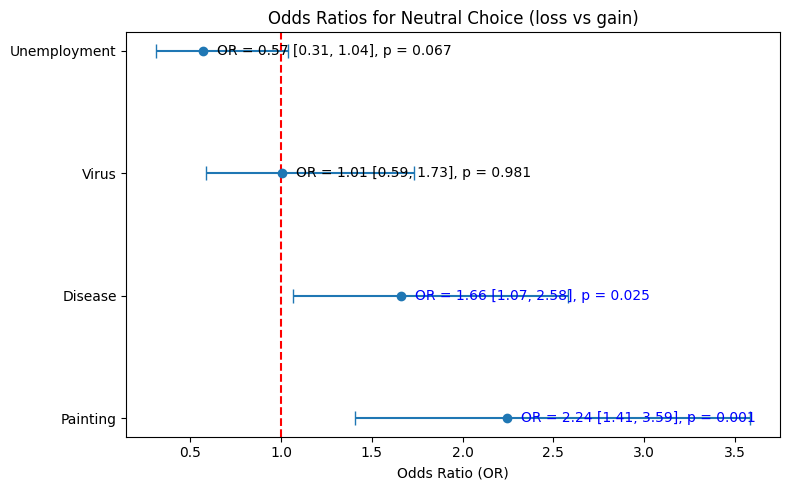

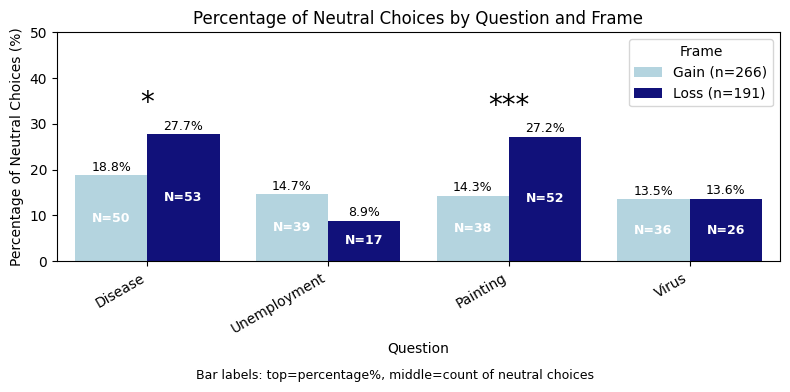

In [10]:
# 2. Logistic regression analysis
# 1. Run the analysis
results = perform_logistic_regression_main(df_strict)

# 2. Create visualizations
forest_plot, bar_chart = visualize_neutral_preference_analysis(results)

In [11]:
# Save the figures
if forest_plot:
    forest_plot.savefig(os.path.join(output_path, 'neutral_choice_forest_strict.png'), dpi=300)
if bar_chart:
    bar_chart.savefig(os.path.join(output_path, 'neutral_choice_bar_strict.png'), dpi=300)
    

##### 2. Less strict data filtered by frame and catch trial

In [12]:
# 1. chi-square
chi_square_df = perform_chi_square_analysis(
    df_less_strict, 
    filter_column='main', 
    filter_value=True
)


Analysis Results: gain vs loss frames - Neutral Choice Analysis
Chi-Square significant results (p < 0.05): 3 out of 4
Z-test significant results (p < 0.05): 3 out of 4


,question,gain_neutral_count,gain_total,gain_neutral_pct,loss_neutral_count,loss_total,loss_neutral_pct,difference,odds_ratio,odds_ratio_lower,...,significant_chi2,cramer_v,cramer_v_lower,cramer_v_upper,effect_size_chi2,z_stat,p_z,significant_z,cohens_h,effect_size_z
0,Disease,79,375,21.066667,76,255,29.803922,-8.737255,0.628601,0.436142,...,True,0.095820,0.017840,0.172642,Small,-2.499300,0.012444,True,0.201293,Medium
1,Unemployment,66,375,17.600000,22,255,8.627451,8.972549,2.262136,1.356231,...,True,0.122382,0.044695,0.198597,Small,3.188826,0.001429,True,0.269597,Medium
2,Painting,51,375,13.600000,70,255,27.450980,-13.850980,0.416005,0.277879,...,True,0.168485,0.091576,0.243396,Small,-4.331965,0.000015,True,0.347537,Medium
3,Virus,49,375,13.066667,42,255,16.470588,-3.403922,0.762270,0.487576,...,False,0.042929,-0.035304,0.120638,Small,-1.192945,0.232891,False,0.096089,Small


Logistic Regression Results: loss vs gain (reference)
Testing if neutral option (value=2) is preferred more in loss frame
Questions analyzed: 4
Significant results (p < 0.05): 3

Odds Ratios (OR > 1 means higher likelihood of neutral choice in {comparison_frame}):


,question,gain_neutral_count,gain_total,gain_neutral_pct,loss_neutral_count,loss_total,loss_neutral_pct,coefficient,coeff_ci_lower,coeff_ci_upper,std_error,model_df,odds_ratio,ci_lower,ci_upper,z_value,p_value,significant
0,Disease,79,375,21.066667,76,255,29.803922,0.464259,0.098725,0.829793,0.186497,1,1.590835,1.103770,2.292829,2.489367,0.012797,True
1,Unemployment,66,375,17.600000,22,255,8.627451,-0.816309,-1.327919,-0.304700,0.261025,1,0.442060,0.265031,0.737338,-3.127321,0.001764,True
2,Painting,51,375,13.600000,70,255,27.450980,0.877057,0.473538,1.280576,0.205877,1,2.403816,1.605677,3.598687,4.260101,0.000020,True
3,Virus,49,375,13.066667,42,255,16.470588,0.271455,-0.175408,0.718317,0.227991,1,1.311871,0.839121,2.050962,1.190636,0.233797,False


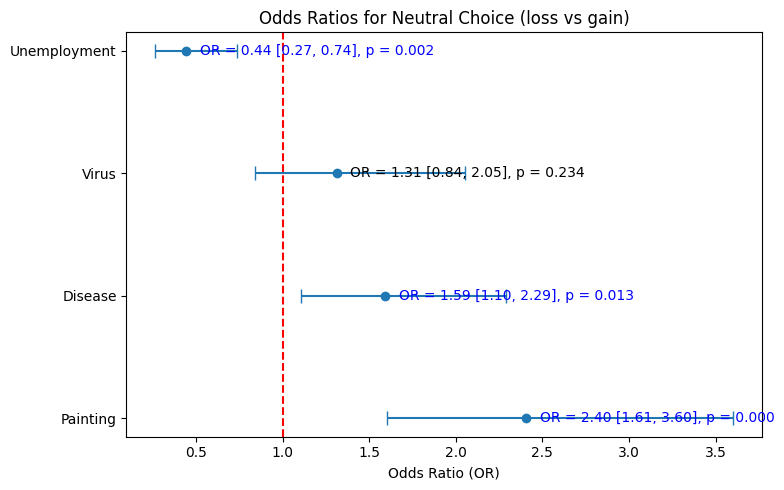

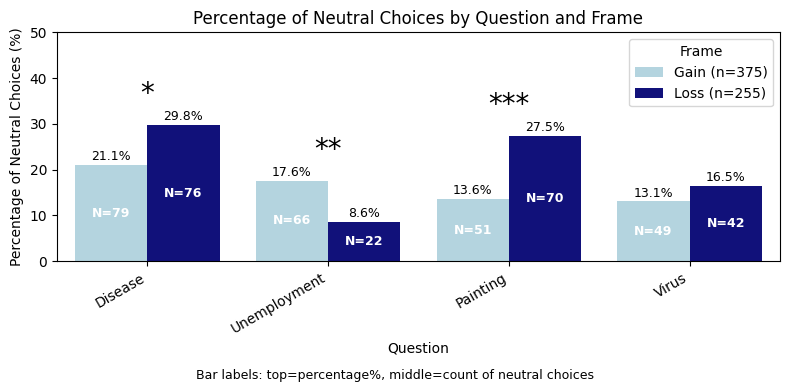

In [13]:
# 2. Logistic regression analysis
# 1. Run the analysis
results = perform_logistic_regression_main(df_less_strict)

# 2. Create visualizations
forest_plot, bar_chart = visualize_neutral_preference_analysis(results)

In [14]:
# Save the figures
if forest_plot:
    forest_plot.savefig(os.path.join(output_path, 'neutral_choice_forest_less_strict.png'), dpi=300)
if bar_chart:
    bar_chart.savefig(os.path.join(output_path, 'neutral_choice_bar_less_strict.png'), dpi=300)
    

##### 3. Super strict data filtered by frame, catch trial, probability question, and <span style="color:red">Control Question</span>


In [15]:
# 1. chi-square
chi_square_df = perform_chi_square_analysis(
    df_super_strict, 
    filter_column='main', 
    filter_value=True
)


Analysis Results: gain vs loss frames - Neutral Choice Analysis
Chi-Square significant results (p < 0.05): 2 out of 3
Z-test significant results (p < 0.05): 2 out of 3


,question,gain_neutral_count,gain_total,gain_neutral_pct,loss_neutral_count,loss_total,loss_neutral_pct,difference,odds_ratio,odds_ratio_lower,...,significant_chi2,cramer_v,cramer_v_lower,cramer_v_upper,effect_size_chi2,z_stat,p_z,significant_z,cohens_h,effect_size_z
0,Disease,27,183,14.754098,33,137,24.087591,-9.333493,0.545455,0.309735,...,True,0.110232,0.000599,0.217247,Small,-2.116619,0.034292,True,0.237506,Medium
1,Painting,25,183,13.661202,38,137,27.737226,-14.076024,0.412225,0.234575,...,True,0.167216,0.058651,0.271872,Small,-3.133314,0.001728,True,0.352157,Medium
2,Virus,25,183,13.661202,20,137,14.598540,-0.937338,0.925633,0.490660,...,False,0.004258,-0.105431,0.113845,Small,-0.238663,0.811367,False,0.026913,Small


Logistic Regression Results: loss vs gain (reference)
Testing if neutral option (value=2) is preferred more in loss frame
Questions analyzed: 3
Significant results (p < 0.05): 2

Odds Ratios (OR > 1 means higher likelihood of neutral choice in {comparison_frame}):


,question,gain_neutral_count,gain_total,gain_neutral_pct,loss_neutral_count,loss_total,loss_neutral_pct,coefficient,coeff_ci_lower,coeff_ci_upper,std_error,model_df,odds_ratio,ci_lower,ci_upper,z_value,p_value,significant
0,Disease,27,183,14.754098,33,137,24.087591,0.606136,0.040223,1.172049,0.288731,1,1.833333,1.041053,3.228568,2.099308,0.035790,True
1,Painting,25,183,13.661202,38,137,27.737226,0.886186,0.322380,1.449991,0.287656,1,2.425859,1.380423,4.263032,3.080714,0.002065,True
2,Virus,25,183,13.661202,20,137,14.598540,0.077278,-0.557460,0.712015,0.323846,1,1.080342,0.572668,2.038071,0.238624,0.811397,False


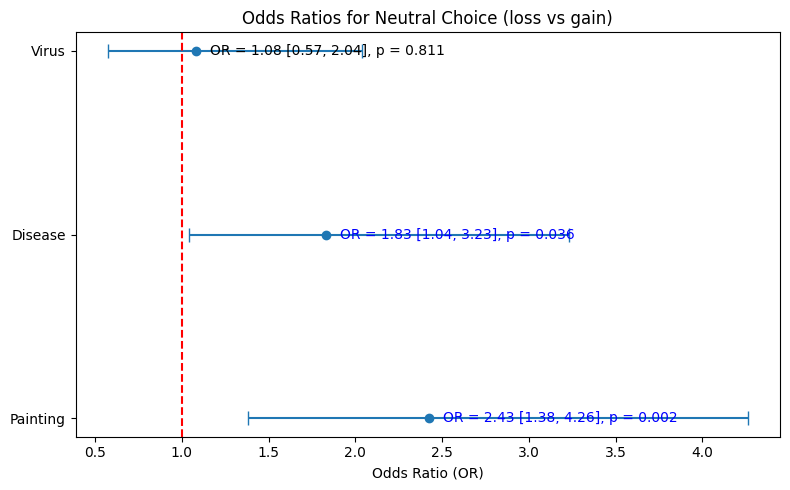

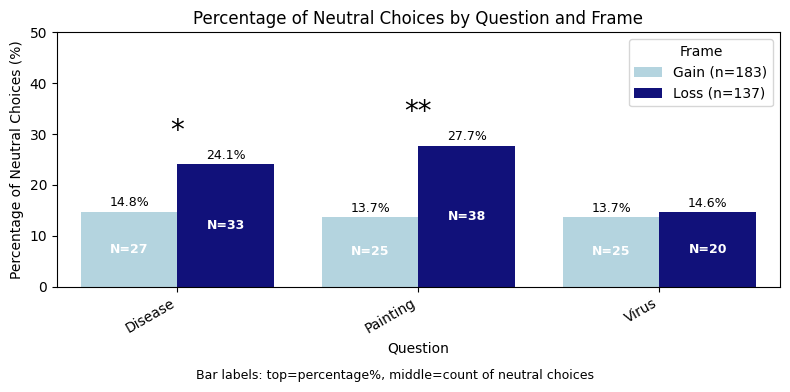

In [16]:
# 2. Logistic regression analysis
# 1. Run the analysis
results = perform_logistic_regression_main(df_super_strict)

# 2. Create visualizations
forest_plot, bar_chart = visualize_neutral_preference_analysis(results)

In [17]:
# Save the figures
if forest_plot:
    forest_plot.savefig(os.path.join(output_path, 'neutral_choice_forest_super_strict.png'), dpi=300)
if bar_chart:
    bar_chart.savefig(os.path.join(output_path, 'neutral_choice_bar_super_strict.png'), dpi=300)


## 2. Sure vs. Risky (ternary)

#### Question: Test classic framing effect in main task

#### Logistic Regression

In [18]:
# Logistic regression function for classic framing effect (between sure and risky choices)
def perform_logistic_regression_classic(df, 
                                    choice_column='choice',
                                    frame_column='frame', 
                                    question_column='question',
                                    task='main',
                                    participant_column='participant_id',
                                    sure_value=0,
                                    frame_values=('gain', 'loss'),
                                    reference_frame='gain',
                                    alpha=0.05):
    """
    Analyze if frame predicts choice (sure or risky) in both main and follow-up questions using logistic regression.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The dataframe containing the choice data.
    choice_column : str, optional
        Column name for choice. Default is 'choice'.
    frame_column : str, optional
        Column name for frame. Default is 'frame'.
    question_column : str, optional
        Column name for question. Default is 'question'.
    task : str, optional
        Column name for main/follow-up indicator. Default is 'main'.
    participant_column : str, optional
        Column name for participant ID. Default is 'participant_id'.
    sure_value : int or str, optional
        Value representing "sure" choice. Default is 0.
    frame_values : tuple, optional
        The two frame values to compare. Default is ('gain', 'loss').
    reference_frame : str, optional
        Reference frame for comparison. Default is 'gain'.
    alpha : float, optional
        Significance level. Default is 0.05.
        
    Returns:
    --------
    pandas.DataFrame
        Detailed results of logistic regression models for each question.
    """
        
    # Ensure we're using the correct frames
    if reference_frame not in frame_values:
        raise ValueError(f"Reference frame '{reference_frame}' must be one of {frame_values}")
    
    comparison_frame = frame_values[0] if frame_values[1] == reference_frame else frame_values[1]
    
    # 1. Filter data based on task type
    if task == 'main':
        data = df[(df[task] == True) & (df['choice'] != 2)].copy()
    else:
        data = df[df[task] == True].copy()
    
    # 2. Set up result container
    results = []
    
    # 3. Process each question individually
    for question in data['question'].unique():
        question_data = data[data[question_column] == question].copy()
        
        # Skip if too few observations
        if len(question_data) < 10:
            print(f"Skipping question '{question}': too few observations ({len(question_data)})")
            print(f'The sample size is {len(question_data)}')
            continue
            
        # Create binary outcome: 1 if sure choice, 0 otherwise
        question_data['is_sure'] = (question_data[choice_column] == sure_value).astype(int)
        
        # Create dummy for frame (1 for comparison frame, 0 for reference)
        question_data['frame_dummy'] = (question_data[frame_column] == comparison_frame).astype(int)
        
        # Calculate raw proportions for reference
        frame_ref = question_data[question_data[frame_column] == reference_frame]
        frame_comp = question_data[question_data[frame_column] == comparison_frame]
        
        # Count sure choices in each frame
        sure_ref_count = frame_ref['is_sure'].sum()
        sure_comp_count = frame_comp['is_sure'].sum()
        
        sure_pct_ref = 100 * sure_ref_count / len(frame_ref) if len(frame_ref) > 0 else 0
        sure_pct_comp = 100 * sure_comp_count / len(frame_comp) if len(frame_comp) > 0 else 0
        
        # Skip if no variation in outcome or predictor
        if question_data['is_sure'].var() == 0 or question_data['frame_dummy'].var() == 0:
            print(f"Skipping question '{question}': no variation in outcome or predictor")
            continue
            
        try:
            # Run logistic regression
            X = sm.add_constant(question_data['frame_dummy'])
            y = question_data['is_sure']
            
            model = sm.Logit(y, X)
            result = model.fit(disp=False)
            
            # Extract results
            coef = result.params['frame_dummy']
            std_err = result.bse['frame_dummy']
            p_value = result.pvalues['frame_dummy']
            
            # Calculate odds ratio and confidence intervals
            odds_ratio = np.exp(coef)
            conf_int = np.exp(result.conf_int().loc['frame_dummy'])
            
            # Calculate confidence intervals for coefficients
            coef_ci_lower = coef - 1.96 * std_err
            coef_ci_upper = coef + 1.96 * std_err
            
            # Store results
            results.append({
                'question': question,
                'participants': len(question_data[participant_column].unique()),
                'observations': len(question_data),
                f'{reference_frame}_sure_count': sure_ref_count,
                f'{reference_frame}_total': len(frame_ref),
                f'{reference_frame}_sure_pct': sure_pct_ref,
                f'{comparison_frame}_sure_count': sure_comp_count,
                f'{comparison_frame}_total': len(frame_comp),
                f'{comparison_frame}_sure_pct': sure_pct_comp,
                'difference_pct': sure_pct_comp - sure_pct_ref,
                'coefficient': coef,
                'std_error': std_err,
                'z_value': coef / std_err,
                'coeff_ci_lower': coef_ci_lower,
                'coeff_ci_upper': coef_ci_upper,
                'p_value': p_value,
                'odds_ratio': odds_ratio,
                'ci_lower': conf_int[0],
                'ci_upper': conf_int[1],
                'significant': p_value < alpha,
                'odds_ratio_interpretation': 
                    f"{'Higher' if odds_ratio > 1 else 'Lower'} odds of sure choice in {comparison_frame} frame" 
                    if p_value < alpha else "No significant difference"
            })
        except Exception as e:
            print(f"Error analyzing question '{question}': {str(e)}")
    
    # 4. Create summary dataframe
    results_df = pd.DataFrame(results)
    
    # 5. Print summary
    if len(results_df) > 0:
        print(f"Follow-up Questions: Logistic Regression Analysis")
        print(f"Predicting sure choice (value={sure_value}) from frame ({comparison_frame} vs {reference_frame})")
        print(f"Questions analyzed: {len(results_df)}")
        print(f"Significant frame effects (p < {alpha}): {sum(results_df['significant'])}")
        
        # Display key results
        display_cols = [
            'question',
            f'{reference_frame}_sure_pct', 
            f'{comparison_frame}_sure_pct',
            'difference_pct',
            'z_value',
            'coefficient',
            'coeff_ci_lower',
            'coeff_ci_upper',
            'std_error',
            'odds_ratio',
            'ci_lower',
            'ci_upper',
            'p_value',
            'significant'
        ]
        
        # Round numeric columns for display
        display_df = results_df[display_cols].copy()
        for col in display_df.columns:
            if display_df[col].dtype in [np.float64, np.float32]:
                display_df[col] = display_df[col].round(3)
        
        display(display_df)
    else:
        print("No valid results to display.")
    
    return results_df

#### Visualization

In [19]:
# Visualization
def visualize_logistic_regression_classic(results_df, 
                                            reference_frame='gain',
                                            task='main',
                                            control=None):
    """
    Create visualizations for logistic regression analysis of frame effects on choices in both main and follow-up tasks.
    
    Parameters:
    -----------
    results_df : pandas.DataFrame
        Results dataframe from analyze_followup_frame_effect().
    reference_frame : str, optional
        Reference frame used in the analysis. Default is 'gain'.
    
    Returns:
    --------
    tuple
        (fig_forest, fig_bar) - forest plot and bar chart figures
    """
    
    if len(results_df) == 0:
        print("No results to visualize.")
        return None, None
    
    comparison_frame = 'loss' if reference_frame == 'gain' else 'gain'
    
    # 1. Forest plot of odds ratios
    fig_forest, ax_forest = plt.subplots(figsize=(8, 4))
    
    # Sort by odds ratio
    results_sorted = results_df.sort_values('odds_ratio', ascending=False)
    
    # Plot odds ratios and confidence intervals
    y_pos = np.arange(len(results_sorted))
    
    # Add reference line at OR = 1
    ax_forest.axvline(x=1, color='red', linestyle='--')
    
    # Plot the points and error bars
    ax_forest.errorbar(
        x=results_sorted['odds_ratio'],
        y=y_pos,
        xerr=[results_sorted['odds_ratio'] - results_sorted['ci_lower'], 
                results_sorted['ci_upper'] - results_sorted['odds_ratio']],
        fmt='o',
        capsize=5
    )
    
    # Customize plot
    ax_forest.set_yticks(y_pos)
    ax_forest.set_yticklabels(results_sorted['question'])
    ax_forest.set_xlabel('Odds Ratio (OR)')
    ax_forest.set_title(f'Odds of Sure Choice: {comparison_frame} vs {reference_frame} Frame')
    
    # Add annotations for each point
    for i, row in enumerate(results_sorted.itertuples()):
        color = 'blue' if row.significant else 'black'
        ax_forest.annotate(
            f'OR = {row.odds_ratio:.2f} [{row.ci_lower:.2f}, {row.ci_upper:.2f}], p = {row.p_value:.3f}',
            xy=(row.odds_ratio, i),
            xytext=(10, 0),
            textcoords='offset points',
            va='center',
            color=color
        )
    
    plt.tight_layout()
    
    # 2. Bar chart of sure choice percentages
    fig_bar, ax_bar = plt.subplots(figsize=(10, 6))
    
    # Create a proper order for questions
    if control == 'exclude':
        questions_order = ["Disease", "Painting", "Virus"]
    else:
        questions_order = ["Disease", "Unemployment", "Painting", "Virus"]
    frames_order = [reference_frame, comparison_frame]
    
    # Prepare data for plotting
    plot_data = []
    
    for question in questions_order:
        row = results_df[results_df['question'] == question].iloc[0]
        
        # Add reference frame data
        plot_data.append({
            'question': question,
            'frame': reference_frame,
            'percentage': row[f'{reference_frame}_sure_pct'],
            'sure_count': row[f'{reference_frame}_sure_count'],
            'total': row[f'{reference_frame}_total']
        })
        
        # Add comparison frame data
        plot_data.append({
            'question': question,
            'frame': comparison_frame,
            'percentage': row[f'{comparison_frame}_sure_pct'],
            'sure_count': row[f'{comparison_frame}_sure_count'],
            'total': row[f'{comparison_frame}_total']
        })
    
    plot_df = pd.DataFrame(plot_data)
    
    # Create grouped bar chart
    sns.barplot(
        x='question',
        y='percentage',
        hue='frame',
        data=plot_df,
        order=questions_order,
        hue_order=frames_order,
        ax=ax_bar
    )
    
    # Add labels to bars
    for i, question in enumerate(questions_order):
        for j, frame in enumerate(frames_order):
            # Get data for this bar
            mask = (plot_df['question'] == question) & (plot_df['frame'] == frame)
            if any(mask):
                data = plot_df.loc[mask].iloc[0]
                
                # Calculate position
                offset = -0.2 if j == 0 else 0.2  # offset for grouped bars
                x_pos = i + offset
                
                # Add percentage at top of bar
                ax_bar.text(
                    x_pos, 
                    data['percentage'] + 1,
                    f"{data['percentage']:.1f}%",
                    ha='center',
                    fontsize=9
                )
                
                # Add sure count in middle of bar
                ax_bar.text(
                    x_pos,
                    data['percentage'] / 2,
                    f"n={int(data['sure_count'])}/{int(data['total'])}",
                    ha='center',
                    va='center',
                    color='white',
                    fontweight='bold',
                    fontsize=9
                )
    
    # Add significance markers
    for i, question in enumerate(questions_order):
        row = results_df[results_df['question'] == question].iloc[0]
        p = row['p_value']  # Make sure this column exists
        if p < 0.001:
            stars = '***'
        elif p < 0.01:
            stars = '**'
        elif p < 0.05:
            stars = '*'
        else:
            stars = ''
            
        if stars:
            max_pct = max(row[f'{reference_frame}_sure_pct'], row[f'{comparison_frame}_sure_pct'])
            ax_bar.text(i, max_pct + 5, stars, ha='center', fontsize=20)
    
    # Customize plot
    ax_bar.set_title(f'Percentage of Sure Choices by Question and Frame in {task.capitalize()} Task')
    ax_bar.set_xlabel('Question')
    ax_bar.set_ylabel('Percentage of Sure Choices (%)')
    ax_bar.set_ylim(0, 100)
    plt.xticks(rotation=30, ha='right')
    
    # Add legend explaining bar labels
    plt.figtext(0.5, 0.01, 
                "Bar labels: percentage of sure choices (top), count of sure choices/total (middle)", 
                ha='center', fontsize=9)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    
    return fig_forest, fig_bar

#### 1. Strict criteria

In [20]:
# Run logistic analysis
logistic_regression_classic_main_strict = perform_logistic_regression_classic(df_strict,
                                                                        reference_frame = 'gain',
                                                                        task = 'main',)

Follow-up Questions: Logistic Regression Analysis
Predicting sure choice (value=0) from frame (loss vs gain)
Questions analyzed: 4
Significant frame effects (p < 0.05): 4


,question,gain_sure_pct,loss_sure_pct,difference_pct,z_value,coefficient,coeff_ci_lower,coeff_ci_upper,std_error,odds_ratio,ci_lower,ci_upper,p_value,significant
0,Disease,79.630,23.913,-55.717,-9.641,-2.521,-3.033,-2.008,0.261,0.080,0.048,0.134,0.0,True
1,Unemployment,19.383,78.736,59.352,10.936,2.734,2.244,3.224,0.250,15.400,9.434,25.139,0.0,True
2,Painting,78.947,40.288,-38.660,-7.229,-1.715,-2.180,-1.250,0.237,0.180,0.113,0.286,0.0,True
3,Virus,70.000,28.485,-41.515,-7.870,-1.768,-2.208,-1.328,0.225,0.171,0.110,0.265,0.0,True


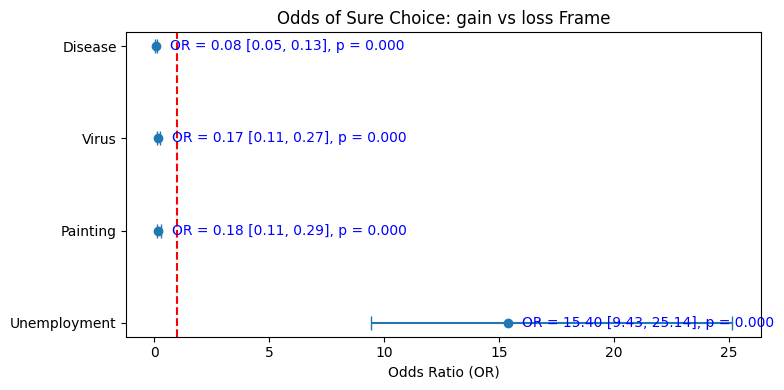

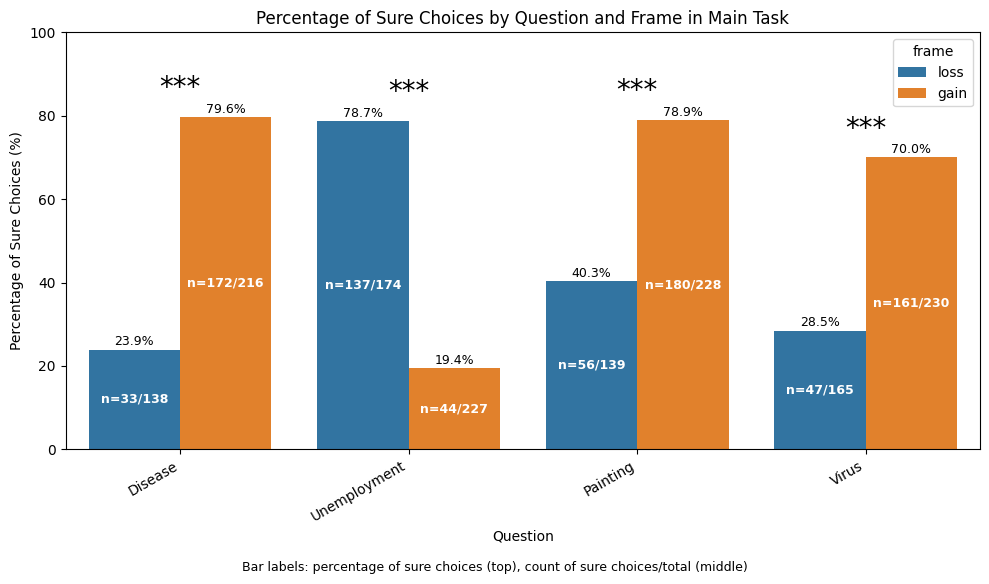

In [21]:
# Visualize the results
fig_forest, fig_bar = visualize_logistic_regression_classic(logistic_regression_classic_main_strict,
                                                                        reference_frame='loss',
                                                                        task='main')

In [22]:
# Save the figures
if fig_forest:
    fig_forest.savefig(os.path.join(output_path, 'sure_choice_classic_main_forest_strict.png'), dpi=300)
if fig_bar:
    fig_bar.savefig(os.path.join(output_path, 'sure_choice_classic_main_bar_strict.png'), dpi=300)
    

#### 2. Less strict criteria

In [23]:
# Run logistic analysis
logistic_regression_classic_main_not_strict = perform_logistic_regression_classic(df_less_strict,
                                                                        reference_frame = 'gain',
                                                                        task = 'main',)

Follow-up Questions: Logistic Regression Analysis
Predicting sure choice (value=0) from frame (loss vs gain)
Questions analyzed: 4
Significant frame effects (p < 0.05): 4


,question,gain_sure_pct,loss_sure_pct,difference_pct,z_value,coefficient,coeff_ci_lower,coeff_ci_upper,std_error,odds_ratio,ci_lower,ci_upper,p_value,significant
0,Disease,78.378,25.140,-53.239,-10.680,-2.379,-2.816,-1.942,0.223,0.093,0.060,0.143,0.0,True
1,Unemployment,22.006,75.107,53.101,11.589,2.370,1.969,2.770,0.204,10.693,7.163,15.965,0.0,True
2,Painting,76.235,41.081,-35.153,-7.692,-1.526,-1.915,-1.137,0.198,0.217,0.147,0.321,0.0,True
3,Virus,68.712,30.986,-37.726,-8.341,-1.587,-1.960,-1.214,0.190,0.204,0.141,0.297,0.0,True


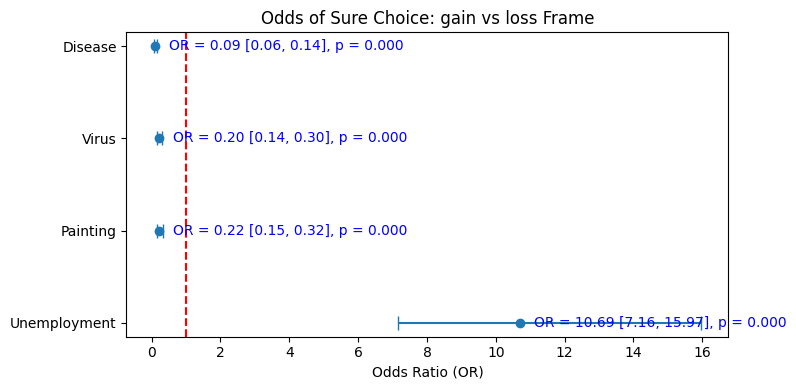

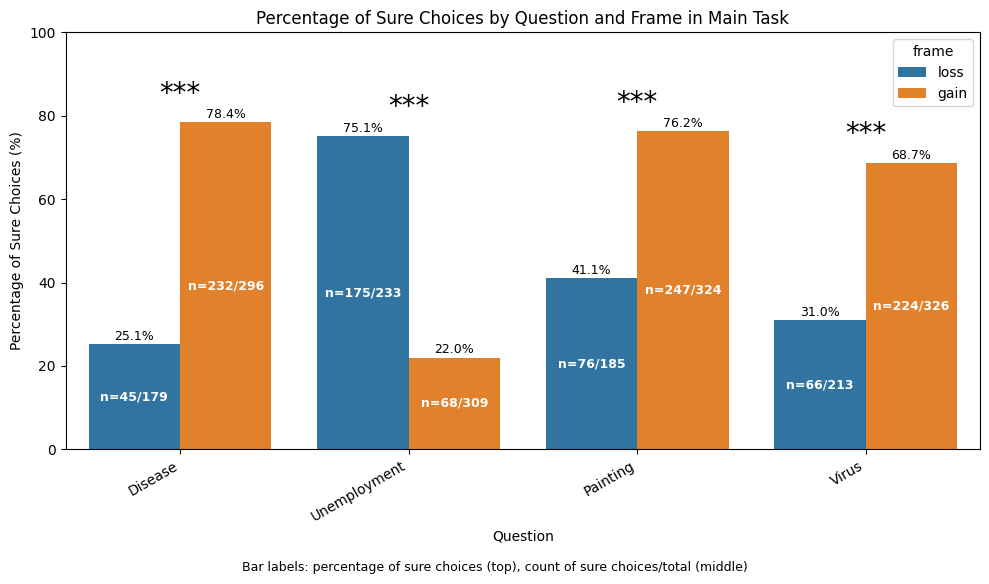

In [24]:
# Visualize the results
fig_forest, fig_bar = visualize_logistic_regression_classic(logistic_regression_classic_main_not_strict,
                                                                        reference_frame='loss',
                                                                        task='main')

In [25]:
# Save the figures
if fig_forest:
    fig_forest.savefig(os.path.join(output_path, 'sure_choice_classic_main_forest_less_strict.png'), dpi=300)
if fig_bar:
    fig_bar.savefig(os.path.join(output_path, 'sure_choice_classic_main_bar_less_strict.png'), dpi=300)
    

#### 3. Super Strict data

In [26]:
# Run logistic analysis
logistic_regression_classic_main_super_strict = perform_logistic_regression_classic(df_super_strict_all_questions,
                                                                        reference_frame = 'gain',
                                                                        task = 'main',)

/Users/jiatong_liu/Documents/GitHub/framing-pilot-analysis/.venv/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/Users/jiatong_liu/Documents/GitHub/framing-pilot-analysis/.venv/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/Users/jiatong_liu/Documents/GitHub/framing-pilot-analysis/.venv/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/Users/jiatong_liu/Documents/GitHub/framing-pilot-analysis/.venv/lib/python3.11/site-packages/statsmodels/discrete/

Follow-up Questions: Logistic Regression Analysis
Predicting sure choice (value=0) from frame (loss vs gain)
Questions analyzed: 4
Significant frame effects (p < 0.05): 3


,question,gain_sure_pct,loss_sure_pct,difference_pct,z_value,coefficient,coeff_ci_lower,coeff_ci_upper,std_error,odds_ratio,ci_lower,ci_upper,p_value,significant
0,Disease,81.410,25.962,-55.449,-8.307,-2.525,-3.121,-1.929,0.304,8.000000e-02,0.044,0.145,0.000,True
1,Unemployment,0.000,100.000,100.000,0.002,45.638,-57685.137,57776.414,29454.478,6.614954e+19,0.000,inf,0.999,False
2,Painting,81.013,43.434,-37.578,-5.980,-1.715,-2.277,-1.153,0.287,1.800000e-01,0.103,0.316,0.000,True
3,Virus,68.987,29.915,-39.073,-6.224,-1.651,-2.171,-1.131,0.265,1.920000e-01,0.114,0.323,0.000,True


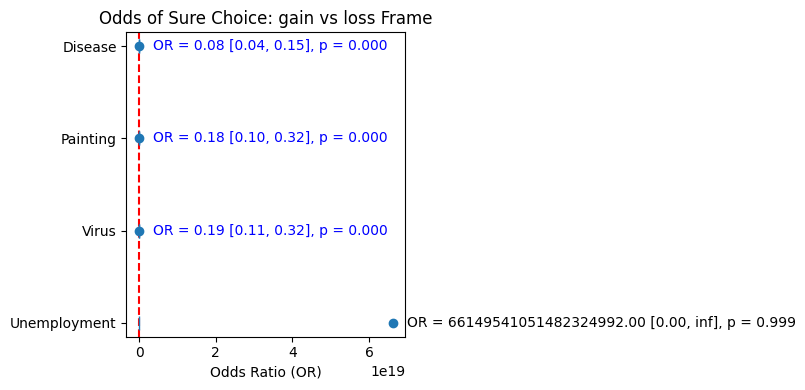

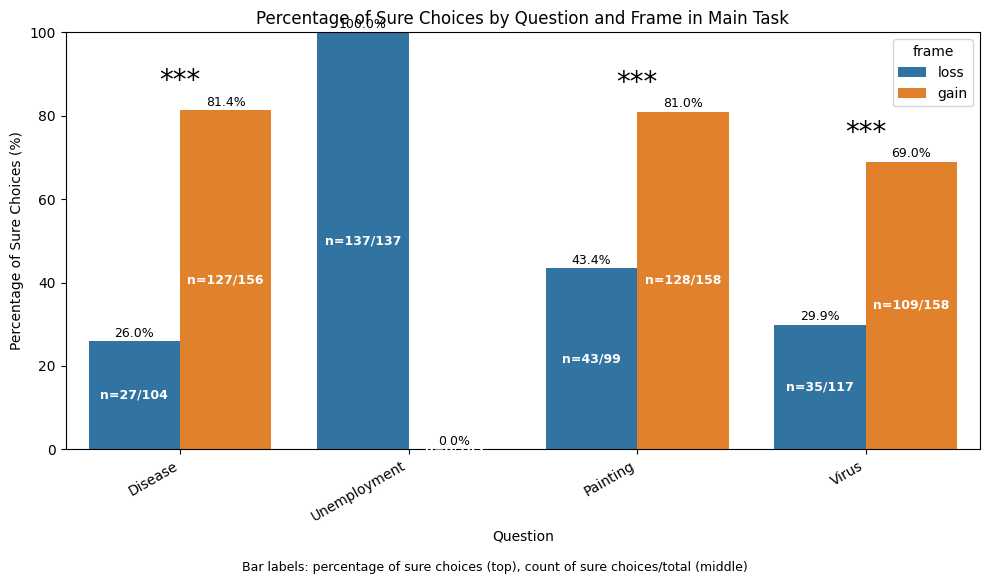

In [27]:
# Visualize the results
fig_forest, fig_bar = visualize_logistic_regression_classic(logistic_regression_classic_main_super_strict,
                                                                        reference_frame='loss',
                                                                        task='main')

In [28]:
# Save the figures
if fig_forest:
    fig_forest.savefig(os.path.join(output_path, 'sure_choice_classic_main_forest_super_strict.png'), dpi=300)
if fig_bar:
    fig_bar.savefig(os.path.join(output_path, 'sure_choice_classic_main_bar_super_strict.png'), dpi=300)


## 3. Sure vs. Risky (binary format)

#### Question: Does framing effect still exist in "neutral" participants?
- Chi-square test of independence (are frame and choice related?)
- Z-test for proportions (are the percentages significantly different?)


##### 1. Chi-square Function

In [29]:
def perform_chi_square_analysis_follow(df, 
                            question_column='question',
                            frame_column='frame', 
                            choice_column='choice',
                            task='follow_up',
                            sure_value=0,
                            frame_values=('gain', 'loss'),
                            alpha=0.05,):
    """
    Analyze differences in "sure" choice percentage between frames for follow-up questions.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The dataframe containing the choice data.
    question_column, frame_column, etc. : str
        Column names in the dataframe.
    sure_value : any
        Value representing "sure" choice.
    frame_values : tuple
        The two frame values to compare.
    alpha : float
        Significance level.
    
    Returns:
    --------
    tuple
        (summary_df, test_results_df, fig) - summary statistics, test results, and figure
    """
    
    # 1. Filter for follow-up questions only
    df_followup = df[df[task] == True].copy()
    
    # 2. Get unique questions
    questions = ['Disease', 'Unemployment', 'Painting', 'Virus']
    
    # 3. Calculate summary statistics
    summary_data = []
    
    for question in questions:
        question_data = df_followup[df_followup[question_column] == question]
        
        for frame in frame_values:
            frame_data = question_data[question_data[frame_column] == frame]
            
            if len(frame_data) > 0:
                sure_count = len(frame_data[frame_data[choice_column] == sure_value])
                total_count = len(frame_data)
                sure_pct = (sure_count / total_count) * 100 if total_count > 0 else 0
                
                summary_data.append({
                    'question': question,
                    'frame': frame,
                    'sure_count': sure_count,
                    'total_count': total_count,
                    'sure_percentage': sure_pct
                })
    
    summary_df = pd.DataFrame(summary_data)
    
    # 4. Run statistical tests
    test_results = []
    
    for question in questions:
        # Get data for this question
        q_data = summary_df[summary_df['question'] == question]
        
        # Skip if we don't have both frames
        if len(q_data) != 2:
            continue
            
        # Extract values for each frame
        frame1_data = q_data[q_data['frame'] == frame_values[0]].iloc[0]
        frame2_data = q_data[q_data['frame'] == frame_values[1]].iloc[0]
        
        # Calculate counts for chi-square test
        counts = np.array([
            [frame1_data['sure_count'], frame2_data['sure_count']],
            [frame1_data['total_count'] - frame1_data['sure_count'], 
            frame2_data['total_count'] - frame2_data['sure_count']]
        ])
        
        # Chi-square test: are frame and choice related?
        chi2, p_chi2, _, _ = stats.chi2_contingency(counts)
        
        # Z-test for proportions: are the percentages significantly different?
        count = np.array([frame1_data['sure_count'], frame2_data['sure_count']])
        nobs = np.array([frame1_data['total_count'], frame2_data['total_count']])
        
        z_stat, p_z = proportions_ztest(count, nobs)
        
        # Effect size (Cohen's h)
        p1 = frame1_data['sure_count'] / frame1_data['total_count']
        p2 = frame2_data['sure_count'] / frame2_data['total_count']
        h = 2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p2))
        
        # Cramer's V for effect size (chi-square)
        n = np.sum(counts)
        cramer_v = np.sqrt(chi2 / (n * (min(counts.shape) - 1)))
        
        # Add results
        test_results.append({
            'question': question,
            f'{frame_values[0]}_sure_pct': frame1_data['sure_percentage'],
            f'{frame_values[1]}_sure_pct': frame2_data['sure_percentage'],
            'difference': frame1_data['sure_percentage'] - frame2_data['sure_percentage'],
            'chi2': chi2,
            'p_chi2': p_chi2,
            'significant_chi2': p_chi2 < alpha,
            'cramer_v': cramer_v,
            'effect_size_chi2': 'Small' if cramer_v < 0.3 else 'Medium' if cramer_v < 0.5 else 'Large',
            'z_stat': z_stat,
            'p_z': p_z,
            'significant_z': p_z < alpha,
            'cohens_h': abs(h),
            'effect_size_z': 'Small' if abs(h) < 0.2 else 'Medium' if abs(h) < 0.5 else 'Large'
        })
    
    test_results_df = pd.DataFrame(test_results)
    
    # Print a summary
    print("\n--- Analysis Summary ---")
    print(f"Analyzing differences in 'sure' choice (value={sure_value}) percentage between {frame_values[0]} and {frame_values[1]} frames")
    print(f"Questions analyzed: {len(test_results_df)}")
    if len(test_results_df) > 0:
        print(f"Significant differences (p < {alpha}) found in {sum(test_results_df['significant_z'])} questions")
    
    return summary_df, test_results_df

##### 1. Strict criteria

In [30]:
# 1. Chi-square analysis
summary_df, test_results = perform_chi_square_analysis_follow(df_strict)

# Display detailed results
print("\n--- Detailed Statistics by Question and Frame ---")
display(summary_df)

print("\n--- Statistical Test Results ---")
display(test_results)


--- Analysis Summary ---
Analyzing differences in 'sure' choice (value=0) percentage between gain and loss frames
Questions analyzed: 4
Significant differences (p < 0.05) found in 4 questions

--- Detailed Statistics by Question and Frame ---


,question,frame,sure_count,total_count,sure_percentage
0,Disease,gain,38,50,76.000000
1,Disease,loss,8,53,15.094340
2,Unemployment,gain,12,39,30.769231
3,Unemployment,loss,11,17,64.705882
4,Painting,gain,28,38,73.684211
5,Painting,loss,19,52,36.538462
6,Virus,gain,23,36,63.888889
7,Virus,loss,6,26,23.076923



--- Statistical Test Results ---


,question,gain_sure_pct,loss_sure_pct,difference,chi2,p_chi2,significant_chi2,cramer_v,effect_size_chi2,z_stat,p_z,significant_z,cohens_h,effect_size_z
0,Disease,76.000000,15.094340,60.905660,36.190844,1.789091e-09,True,0.592763,Large,6.214166,5.159790e-10,True,1.319610,Large
1,Unemployment,30.769231,64.705882,-33.936652,4.318821,3.769304e-02,True,0.277708,Small,-2.373553,1.761788e-02,True,0.693323,Large
2,Painting,73.684211,36.538462,37.145749,10.698618,1.072156e-03,True,0.344780,Medium,3.484502,4.930542e-04,True,0.766064,Large
3,Virus,63.888889,23.076923,40.811966,8.527429,3.498334e-03,True,0.370863,Medium,3.178084,1.482520e-03,True,0.850090,Large


In [31]:
# 2. Logistic regression
# Run logistic analysis
logistic_regression_follow_strict = perform_logistic_regression_classic(df_strict,
                                                                        reference_frame = 'gain',
                                                                        task = 'follow_up',)

Follow-up Questions: Logistic Regression Analysis
Predicting sure choice (value=0) from frame (loss vs gain)
Questions analyzed: 4
Significant frame effects (p < 0.05): 4


,question,gain_sure_pct,loss_sure_pct,difference_pct,z_value,coefficient,coeff_ci_lower,coeff_ci_upper,std_error,odds_ratio,ci_lower,ci_upper,p_value,significant
0,Disease,76.000,15.094,-60.906,-5.682,-2.880,-3.873,-1.887,0.507,0.056,0.021,0.152,0.000,True
1,Virus,63.889,23.077,-40.812,-3.056,-1.775,-2.912,-0.637,0.581,0.170,0.054,0.529,0.002,True
2,Unemployment,30.769,64.706,33.937,2.305,1.417,0.212,2.622,0.615,4.125,1.236,13.763,0.021,True
3,Painting,73.684,36.538,-37.146,-3.383,-1.582,-2.498,-0.665,0.468,0.206,0.082,0.514,0.001,True


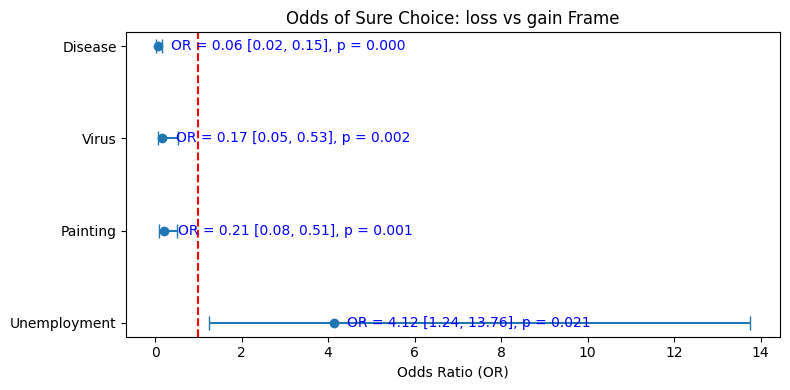

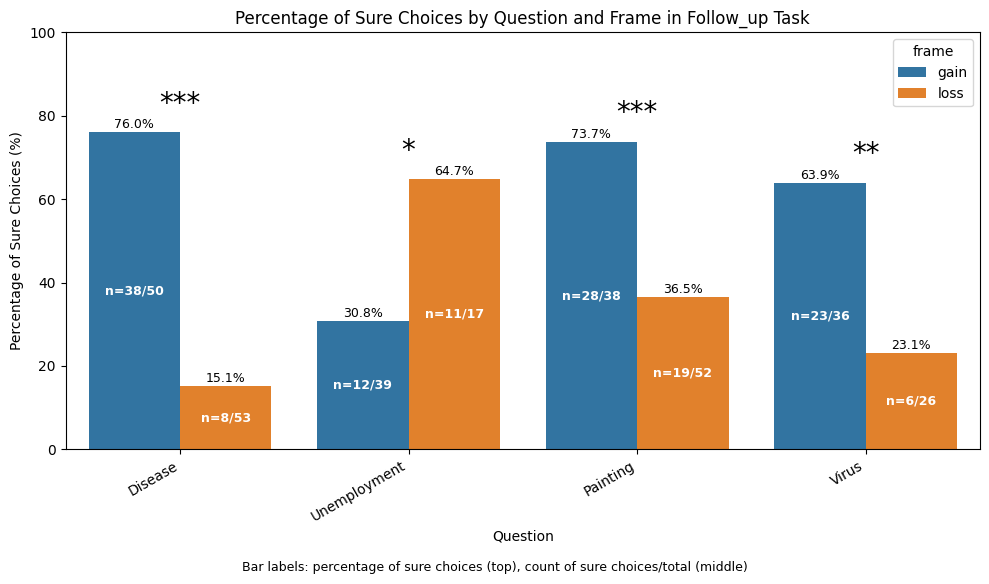

In [32]:
# Visualize the results
fig_forest, fig_bar = visualize_logistic_regression_classic(logistic_regression_follow_strict,
                                                                        reference_frame='gain',
                                                                        task='follow_up')

In [33]:
# Save the figures
fig_bar.savefig(os.path.join(output_path, 'sure_choice_follow_bar_strict.png'), dpi=300)

##### 2. Less Strict 

In [34]:
# 1. Chi-saquare analysis
summary_df, test_results = perform_chi_square_analysis_follow(df_less_strict)

# Display detailed results
print("\n--- Detailed Statistics by Question and Frame ---")
display(summary_df)

print("\n--- Statistical Test Results ---")
display(test_results)


--- Analysis Summary ---
Analyzing differences in 'sure' choice (value=0) percentage between gain and loss frames
Questions analyzed: 4
Significant differences (p < 0.05) found in 4 questions

--- Detailed Statistics by Question and Frame ---


,question,frame,sure_count,total_count,sure_percentage
0,Disease,gain,58,79,73.417722
1,Disease,loss,12,76,15.789474
2,Unemployment,gain,19,66,28.787879
3,Unemployment,loss,14,22,63.636364
4,Painting,gain,37,51,72.549020
5,Painting,loss,28,70,40.000000
6,Virus,gain,30,49,61.224490
7,Virus,loss,13,42,30.952381



--- Statistical Test Results ---


,question,gain_sure_pct,loss_sure_pct,difference,chi2,p_chi2,significant_chi2,cramer_v,effect_size_chi2,z_stat,p_z,significant_z,cohens_h,effect_size_z
0,Disease,73.417722,15.789474,57.628248,49.642044,1.845168e-12,True,0.565925,Large,7.207143,5.713810e-13,True,1.240948,Large
1,Unemployment,28.787879,63.636364,-34.848485,7.127273,7.592012e-03,True,0.284590,Small,-2.923952,3.456181e-03,True,0.714352,Large
2,Painting,72.549020,40.000000,32.549020,11.297563,7.760889e-04,True,0.305562,Medium,3.545798,3.914259e-04,True,0.669221,Large
3,Virus,61.224490,30.952381,30.272109,7.144804,7.518150e-03,True,0.280204,Small,2.883575,3.931893e-03,True,0.617246,Large


In [35]:
# 2. Logistic regression
# Run logistic analysis
logistic_regression_follow_not_strict = perform_logistic_regression_classic(df_less_strict,
                                                                        reference_frame = 'gain',
                                                                        task = 'follow_up',)

Follow-up Questions: Logistic Regression Analysis
Predicting sure choice (value=0) from frame (loss vs gain)
Questions analyzed: 4
Significant frame effects (p < 0.05): 4


,question,gain_sure_pct,loss_sure_pct,difference_pct,z_value,coefficient,coeff_ci_lower,coeff_ci_upper,std_error,odds_ratio,ci_lower,ci_upper,p_value,significant
0,Disease,73.418,15.789,-57.628,-6.646,-2.690,-3.483,-1.897,0.405,0.068,0.031,0.150,0.000,True
1,Virus,61.224,30.952,-30.272,-2.834,-1.259,-2.130,-0.388,0.444,0.284,0.119,0.678,0.005,True
2,Unemployment,28.788,63.636,34.848,2.818,1.465,0.446,2.484,0.520,4.329,1.562,11.994,0.005,True
3,Painting,72.549,40.000,-32.549,-3.465,-1.377,-2.156,-0.598,0.397,0.252,0.116,0.550,0.001,True


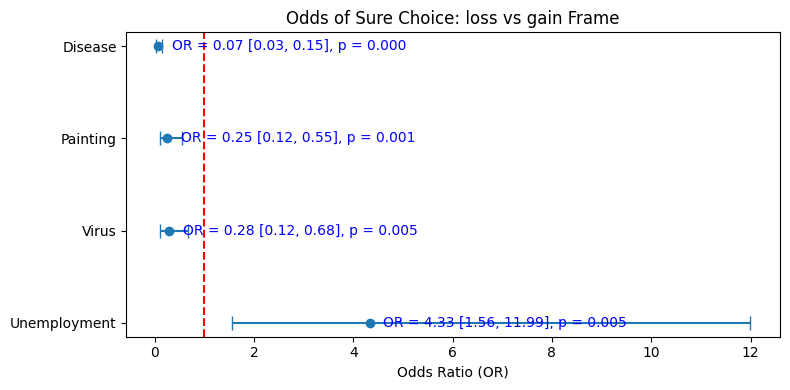

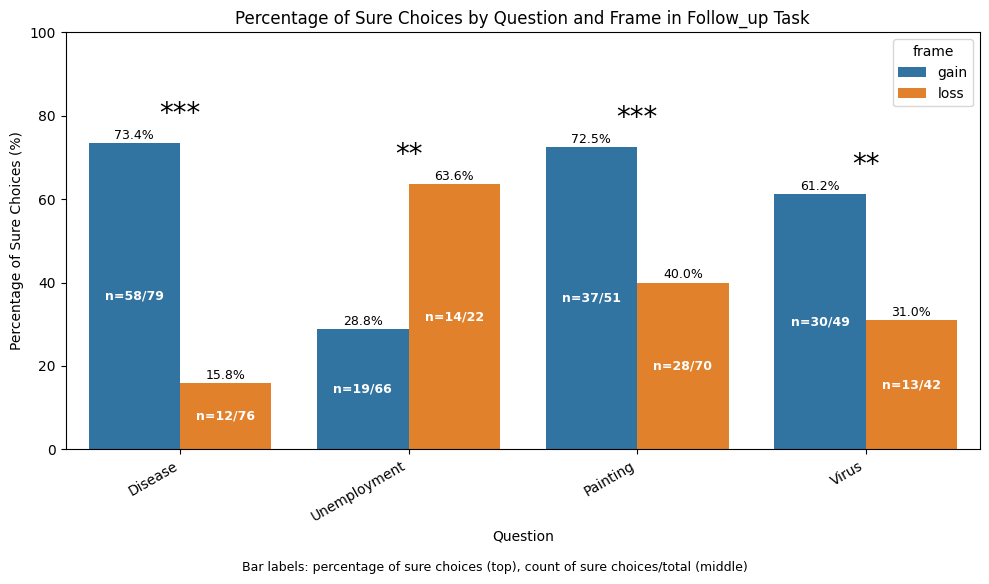

In [36]:
# Visualize the results
fig_forest, fig_bar = visualize_logistic_regression_classic(logistic_regression_follow_not_strict,
                                                                        reference_frame='gain',
                                                                        task='follow_up')

In [37]:
# Save the figures
fig_bar.savefig(os.path.join(output_path, 'sure_choice_follow_bar_less_strict.png'), dpi=300)


##### 3. Super Strict 

In [38]:
# 1. Chi-saquare analysis
summary_df, test_results = perform_chi_square_analysis_follow(df_super_strict)

# Display detailed results
print("\n--- Detailed Statistics by Question and Frame ---")
display(summary_df)

print("\n--- Statistical Test Results ---")
display(test_results)


--- Analysis Summary ---
Analyzing differences in 'sure' choice (value=0) percentage between gain and loss frames
Questions analyzed: 3
Significant differences (p < 0.05) found in 3 questions

--- Detailed Statistics by Question and Frame ---


,question,frame,sure_count,total_count,sure_percentage
0,Disease,gain,18,27,66.666667
1,Disease,loss,5,33,15.151515
2,Painting,gain,21,25,84.000000
3,Painting,loss,17,38,44.736842
4,Virus,gain,15,25,60.000000
5,Virus,loss,5,20,25.000000



--- Statistical Test Results ---


,question,gain_sure_pct,loss_sure_pct,difference,chi2,p_chi2,significant_chi2,cramer_v,effect_size_chi2,z_stat,p_z,significant_z,cohens_h,effect_size_z
0,Disease,66.666667,15.151515,51.515152,14.563259,0.000136,True,0.492667,Medium,4.083050,0.000044,True,1.111000,Large
1,Painting,84.000000,44.736842,39.263158,8.140944,0.004328,True,0.359474,Medium,3.116417,0.001831,True,0.853221,Large
2,Virus,60.000000,25.000000,35.000000,4.186125,0.040756,True,0.305000,Medium,2.347871,0.018881,True,0.724957,Large


In [39]:
# 2. Logistic regression
# Run logistic analysis
logistic_regression_follow_super_strict = perform_logistic_regression_classic(df_super_strict,
                                                                        reference_frame = 'gain',
                                                                        task = 'follow_up',)

Follow-up Questions: Logistic Regression Analysis
Predicting sure choice (value=0) from frame (loss vs gain)
Questions analyzed: 3
Significant frame effects (p < 0.05): 3


,question,gain_sure_pct,loss_sure_pct,difference_pct,z_value,coefficient,coeff_ci_lower,coeff_ci_upper,std_error,odds_ratio,ci_lower,ci_upper,p_value,significant
0,Disease,66.667,15.152,-51.515,-3.809,-2.416,-3.659,-1.173,0.634,0.089,0.026,0.310,0.000,True
1,Virus,60.000,25.000,-35.000,-2.285,-1.504,-2.794,-0.214,0.658,0.222,0.061,0.807,0.022,True
2,Painting,84.000,44.737,-39.263,-2.941,-1.870,-3.115,-0.624,0.636,0.154,0.044,0.536,0.003,True


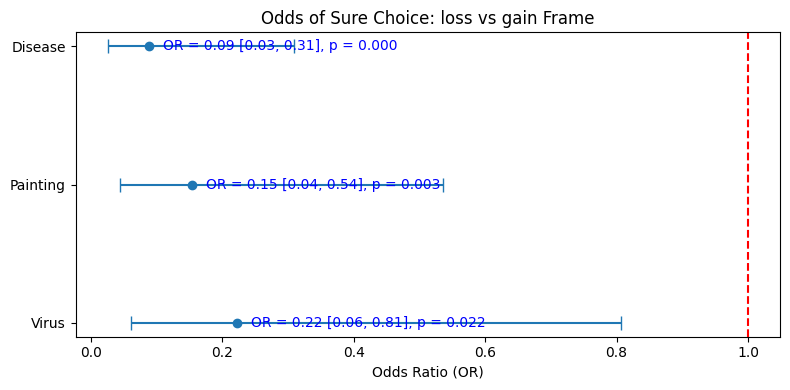

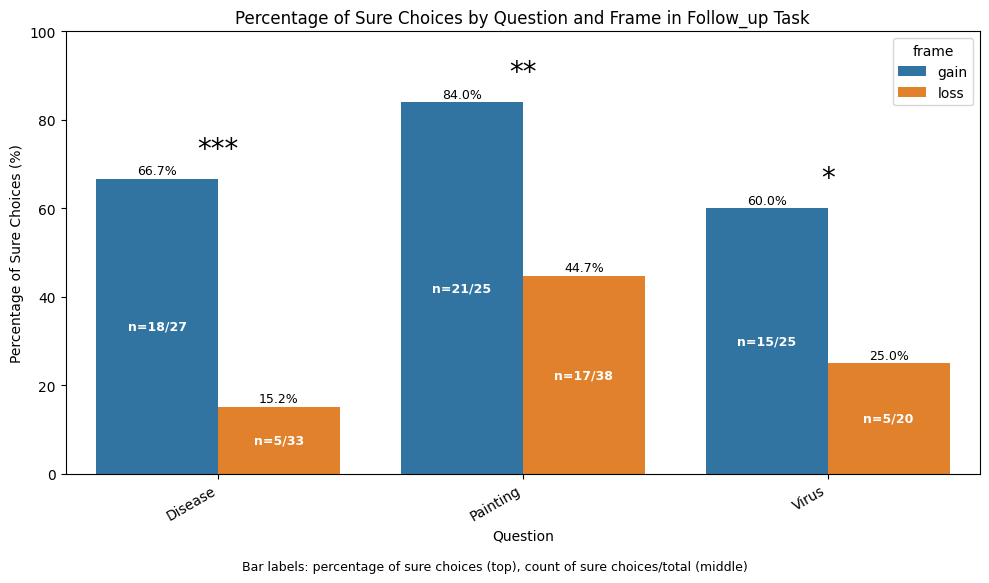

In [40]:
# Visualize the results
fig_forest, fig_bar = visualize_logistic_regression_classic(logistic_regression_follow_super_strict,
                                                                        reference_frame='gain',
                                                                        task='follow_up',
                                                                        control='exclude')

In [41]:
# Save the figures
fig_bar.savefig(os.path.join(output_path, 'sure_choice_follow_bar_super_strict.png'), dpi=300)


## Sample Size Summary

In [42]:
# Sample size (unique participants) for each dataset
print(f'The sample size of strict data is {df_strict["participant_id"].unique().shape[0]}')
print(f'The sample size of less strict data is {df_less_strict["participant_id"].unique().shape[0]}')
print(f'The sample size of super strict data is {df_super_strict_all_questions["participant_id"].unique().shape[0]}')

The sample size of strict data is 457
The sample size of less strict data is 630
The sample size of super strict data is 320
